In [1]:
import torch 


In [2]:
torch.__version__

'2.9.0+cu126'

In [3]:
import torch.nn as nn

In [4]:
class Model(nn.Module):
    def __init__(self,num_features):

        super().__init__()
        self.linear = nn.Linear(num_features,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self,features):
        out = self.linear(features)
        out = self.sigmoid(out)

        return out



In [20]:
# lets create a synthetic dataset of 5 features
features = torch.rand(10,5)
features

tensor([[0.5368, 0.1206, 0.2385, 0.7860, 0.4001],
        [0.7007, 0.5645, 0.1232, 0.6244, 0.7543],
        [0.9431, 0.7080, 0.9863, 0.5501, 0.4796],
        [0.0955, 0.1334, 0.4987, 0.5755, 0.8858],
        [0.3068, 0.1470, 0.6432, 0.4578, 0.7810],
        [0.6737, 0.2322, 0.3571, 0.6399, 0.5668],
        [0.0501, 0.6165, 0.8218, 0.8846, 0.3755],
        [0.7628, 0.6197, 0.0102, 0.9673, 0.6250],
        [0.8003, 0.2968, 0.1980, 0.3680, 0.8752],
        [0.5066, 0.2906, 0.6305, 0.5528, 0.6129]])

In [18]:
# create model 
model = Model(features.shape[1])


In [19]:
model(features)

tensor([[0.4150],
        [0.3993],
        [0.4700],
        [0.4009],
        [0.5326],
        [0.4571],
        [0.4710],
        [0.3940],
        [0.4479],
        [0.3787]], grad_fn=<SigmoidBackward0>)

In [23]:
print(model.linear.weight)
print(model.linear.bias)

Parameter containing:
tensor([[-0.2434, -0.4236, -0.0116,  0.4414,  0.0244]], requires_grad=True)
Parameter containing:
tensor([-0.0797], requires_grad=True)


In [24]:
!pip install torchinfo

In [26]:
from torchinfo import summary
summary(model,size=(10,5))

Layer (type:depth-idx)                   Param #
Model                                    --
├─Linear: 1-1                            6
├─Sigmoid: 1-2                           --
Total params: 6
Trainable params: 6
Non-trainable params: 0

Neural Network with Hidden Layer

In [31]:
class ModelWithHiddenLayers(nn.Module):
    def __init__(self,num_feature):

        super().__init__()
        self.hiddenLayer = nn.Linear(num_feature,3)
        self.relu = nn.ReLU()

        self.layerOne = nn.Linear(3,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self,feature):
        out = self.hiddenLayer(feature)
        out = self.relu(out)

        out = self.layerOne(out)
        out = self.sigmoid(out)

        return out    


In [32]:
# lets create a synthetic dataset of 5 features
features = torch.rand(10,5)
features

tensor([[0.7245, 0.7227, 0.5300, 0.2360, 0.9094],
        [0.3194, 0.2580, 0.5217, 0.8889, 0.9483],
        [0.4321, 0.4975, 0.5912, 0.9035, 0.9603],
        [0.2275, 0.6452, 0.8026, 0.6060, 0.5186],
        [0.7512, 0.6157, 0.6490, 0.6421, 0.5997],
        [0.1877, 0.2772, 0.5722, 0.3870, 0.5319],
        [0.7807, 0.6969, 0.4045, 0.7713, 0.5372],
        [0.4145, 0.1433, 0.1001, 0.6607, 0.7403],
        [0.0026, 0.6857, 0.4643, 0.9162, 0.5425],
        [0.8312, 0.0670, 0.8772, 0.0355, 0.3668]])

In [35]:
# create model 
modelHiddneLayer = ModelWithHiddenLayers(features.shape[1])

In [36]:
modelHiddneLayer(features)

tensor([[0.5009],
        [0.5419],
        [0.5235],
        [0.4660],
        [0.5099],
        [0.5120],
        [0.5026],
        [0.5590],
        [0.4438],
        [0.5299]], grad_fn=<SigmoidBackward0>)

In [40]:
modelHiddneLayer.hiddenLayer.weight.shape

torch.Size([3, 5])

In [39]:
modelHiddneLayer.layerOne.weight.shape

torch.Size([1, 3])

In [42]:
modelHiddneLayer.hiddenLayer.bias.shape

torch.Size([3])

In [44]:
from torchinfo import summary
summary(modelHiddneLayer,size=(10,5))

Layer (type:depth-idx)                   Param #
ModelWithHiddenLayers                    --
├─Linear: 1-1                            18
├─ReLU: 1-2                              --
├─Linear: 1-3                            4
├─Sigmoid: 1-4                           --
Total params: 22
Trainable params: 22
Non-trainable params: 0

In [52]:
class improvedModelWithSequential(nn.Module):
    def __init__(self, num_features):

        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features,3),
            nn.ReLU(),
            nn.Linear(3,1),
            nn.Sigmoid()
        )

    def forward(self, features):
        
        return self.network(features)

In [53]:
feature = torch.rand(10,5)

In [54]:
modelSeq = improvedModelWithSequential(feature.shape[1])

In [55]:
modelSeq(feature)

tensor([[0.6023],
        [0.6061],
        [0.6029],
        [0.6018],
        [0.6141],
        [0.6031],
        [0.6035],
        [0.6092],
        [0.6014],
        [0.6139]], grad_fn=<SigmoidBackward0>)

## Improving Our First NN Model (Scratch) 

In [5]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder



In [7]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')

In [8]:
df.head(2)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN


In [9]:
df.drop(columns=['id', 'Unnamed: 32'],inplace=True)

In [64]:
df.head(1)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189


In [11]:
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,1:],df.iloc[:,0],test_size=0.2)

In [12]:
scaler = StandardScaler()
 
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [14]:
X_train_tensor = torch.from_numpy(X_train)
X_test_tensor = torch.from_numpy(X_test)

y_train_tensor = torch.from_numpy(y_train)
y_test_tensor = torch.from_numpy(y_test)

X_train_tensor = X_train_tensor.float()
X_test_tensor = X_test_tensor.float()

y_train_tensor = y_train_tensor.float()
y_test_tensor = y_test_tensor.float()


## Improving the Previously Created From Scratch Model

In [15]:
learning_rate = 0.1
epochs = 35

In [16]:
class mySimpleModel(nn.Module):
    
    def __init__(self,num_features):

        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features,1),
            nn.Sigmoid()
        )
        self.loss_fn = nn.BCELoss()
        self.optimizer = torch.optim.SGD(self.parameters(),lr=learning_rate)

    def forward(self,feature):
        return self.network(feature)

    def loss_function(self,y_pred,y):
        return self.loss_fn(y_pred,y)



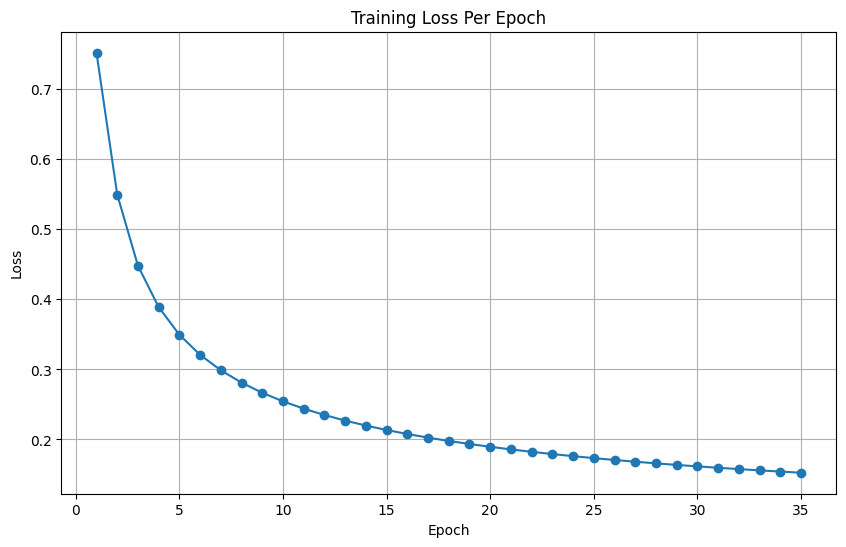

In [20]:
model = mySimpleModel(X_train_tensor.shape[1])
losses = []


for epoch in range(epochs):
    # forward
    y_pred = model(X_train_tensor)

    loss = model.loss_function(y_pred,y_train_tensor.view(-1,1))

    # clear gradients  
    model.optimizer.zero_grad()
    # backward 
    loss.backward()

    # parameters update 

    model.optimizer.step()
    losses.append(loss.item())

    # print(f"Epoch : {epoch+1}, loss : {loss.item()}")
    
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(range(1,epochs+1),losses,marker='o')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Loss Per Epoch")
ax.grid(True)
plt.show()


In [102]:
model.network[0].weight

Parameter containing:
tensor([[ 0.0945,  0.2243,  0.1320,  0.2606,  0.0179,  0.2039,  0.0951,  0.2506,
          0.1364, -0.0205,  0.2366,  0.0674,  0.0565,  0.1252,  0.0226,  0.1269,
         -0.1079,  0.1196,  0.0267, -0.0884,  0.2944,  0.0931,  0.4085,  0.4021,
          0.1421,  0.0593,  0.3968,  0.2398,  0.2611,  0.0019]],
       requires_grad=True)

In [103]:
model.network[0].bias

Parameter containing:
tensor([-0.0487], requires_grad=True)

In [126]:
from torchinfo import summary
summary(model,size = X_train_tensor.shape)

Layer (type:depth-idx)                   Param #
mySimpleModel                            --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       31
│    └─Sigmoid: 2-2                      --
├─BCELoss: 1-2                           --
Total params: 31
Trainable params: 31
Non-trainable params: 0

In [127]:
with torch.no_grad():
    y_pred = model.forward(X_test_tensor)
    y_pred = (y_pred > 0.8).float()
    accuracy = (y_pred == y_test_tensor).float().mean()
    print(f"Accuracy : {accuracy}")

Accuracy : 0.6071099042892456
